## Análisis exploratorio de datos (EDA) - Enfermedad del corazón

### By:
Ronaldo Duran (JRDT)

### Date:
2026-08-21

### Description:

EDA completo del dataset de enfermedad cardíaca, correspondiente al
[issue #10](https://github.com/ronaldo-duran/Hearth-project/issues/10).
Parte del dataset **tipado** producido en el
[issue #8](https://github.com/ronaldo-duran/Hearth-project/issues/8)
(`data/02_intermediate/corazon.parquet`).

Contenido: análisis **univariable** (caracterización atributo por atributo, estadística
descriptiva, forma de la distribución), **bivariable** (relación de cada atributo con el
target) y **multivariable** (correlaciones y estructura conjunta), más las reglas de
validación de datos, las transformaciones candidatas y la evaluación de un **modelo
heurístico viable**.

## 📚 Import libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

## 💾 Load data

In [2]:
current_dir = Path.cwd().resolve()
project_root = next(
    p for p in [current_dir, *current_dir.parents] if (p / "data" / "01_raw").exists()
)

corazon = pd.read_parquet(project_root / "data" / "02_intermediate" / "corazon.parquet")
print(f"Dataset tipado: {corazon.shape[0]} filas x {corazon.shape[1]} columnas")
corazon.dtypes.to_frame("dtype").T

Dataset tipado: 3030 filas x 14 columnas


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
dtype,Int16,category,category,Int16,Int16,boolean,category,Int16,boolean,Float64,Int8,Int8,category,boolean


## 🔁 Duplicados: definir el dataset de análisis

El dataset intermedio conserva a propósito las 3030 filas del RAW. Antes de analizar
nada hay que resolver los duplicados, porque **analizar 3030 filas de las que 2462 son
copias daría una falsa sensación de tamaño muestral**: los intervalos de confianza y
cualquier prueba estadística saldrían artificialmente estrechos.

In [3]:
n_dup = corazon.duplicated().sum()
print(f"Filas duplicadas exactas: {n_dup} ({n_dup / len(corazon):.1%})")

# Dataset de analisis: sin duplicados y solo con target valido
corazon_eda = corazon.drop_duplicates().dropna(subset=["disease"]).reset_index(drop=True)

print(f"Tras deduplicar:            {len(corazon.drop_duplicates())} filas")
print(f"Tras exigir target valido:  {len(corazon_eda)} filas  <- dataset de analisis")
print(f"Reduccion respecto al RAW:  {1 - len(corazon_eda) / len(corazon):.1%}")

Filas duplicadas exactas: 2462 (81.3%)
Tras deduplicar:            568 filas
Tras exigir target valido:  480 filas  <- dataset de analisis
Reduccion respecto al RAW:  84.2%


El tamaño muestral real es de un par de centenares de pacientes, no de miles. Esto
condiciona todo el proyecto: modelos simples, validación cruzada obligatoria y prudencia
con cualquier conclusión basada en subgrupos pequeños.

## 1️⃣ Análisis univariable

### Caracterización de cada atributo

In [4]:
TIPO_SEMANTICO = {
    "age": "numérico discreto (años)",
    "sex": "categórico nominal",
    "chest_pain": "categórico nominal",
    "rest_bp": "numérico discreto (mm Hg)",
    "chol": "numérico discreto (mg/dl)",
    "fbs": "booleano",
    "rest_ecg": "categórico nominal",
    "max_hr": "numérico discreto (lpm)",
    "exang": "booleano",
    "old_peak": "numérico continuo",
    "slope": "categórico ordinal (1 < 2 < 3)",
    "ca": "numérico discreto / conteo (0-3)",
    "thal": "categórico nominal",
    "disease": "booleano (TARGET)",
}

caracterizacion = pd.DataFrame(
    {
        "tipo_semantico": pd.Series(TIPO_SEMANTICO),
        "dtype": corazon_eda.dtypes.astype(str),
        "nulos": corazon_eda.isna().sum(),
        "pct_nulos": (corazon_eda.isna().mean() * 100).round(2),
        "valores_unicos": corazon_eda.nunique(),
    }
)
caracterizacion

,tipo_semantico,dtype,nulos,pct_nulos,valores_unicos
age,numérico discreto (años),Int16,17,3.54,41
sex,categórico nominal,category,49,10.21,2
chest_pain,categórico nominal,category,71,14.79,4
rest_bp,numérico discreto (mm Hg),Int16,68,14.17,50
chol,numérico discreto (mg/dl),Int16,72,15.00,152
fbs,booleano,boolean,82,17.08,2
rest_ecg,categórico nominal,category,116,24.17,3
max_hr,numérico discreto (lpm),Int16,90,18.75,91
exang,booleano,boolean,71,14.79,2
old_peak,numérico continuo,Float64,70,14.58,40


In [5]:
# Duplicados por columna (columnas identicas entre si)
columnas_duplicadas = [
    (a, b)
    for i, a in enumerate(corazon_eda.columns)
    for b in corazon_eda.columns[i + 1 :]
    if corazon_eda[a].equals(corazon_eda[b])
]
print(f"Columnas exactamente duplicadas: {columnas_duplicadas or 'ninguna'}")
print(f"Filas duplicadas en el dataset de analisis: {corazon_eda.duplicated().sum()}")

Columnas exactamente duplicadas: ninguna
Filas duplicadas en el dataset de analisis: 0


### Descripción estadística de los atributos numéricos

Se calculan tendencia central, dispersión y **forma de la distribución** (skewness y
kurtosis), que es lo que decide qué transformaciones hacen falta más adelante.

In [6]:
NUMERICAS = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]

desc = corazon_eda[NUMERICAS].astype("Float64").astype(float).describe().T
desc["rango"] = desc["max"] - desc["min"]
desc["IQR"] = desc["75%"] - desc["25%"]
desc["varianza"] = corazon_eda[NUMERICAS].astype(float).var()
desc["skewness"] = corazon_eda[NUMERICAS].astype(float).skew()
desc["kurtosis"] = corazon_eda[NUMERICAS].astype(float).kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,rango,IQR,varianza,skewness,kurtosis
age,463.0,54.572,8.901,29.0,48.0,56.0,61.00,77.0,48.0,13.00,79.237,-0.245,-0.599
rest_bp,412.0,131.677,17.321,94.0,120.0,130.0,140.00,200.0,106.0,20.00,300.020,0.627,0.665
chol,408.0,247.395,52.964,126.0,211.0,242.5,276.25,564.0,438.0,65.25,2805.134,1.297,5.586
max_hr,390.0,149.744,22.255,71.0,138.0,152.0,165.00,202.0,131.0,27.00,495.297,-0.544,0.039
old_peak,410.0,1.089,1.214,0.0,0.0,0.8,1.80,6.2,6.2,1.80,1.475,1.266,1.533
ca,433.0,0.661,0.932,0.0,0.0,0.0,1.00,3.0,3.0,1.00,0.868,1.190,0.236


In [7]:
# Prueba de normalidad (Shapiro-Wilk) para clasificar el tipo de distribucion
filas = []
for col in NUMERICAS:
    serie = corazon_eda[col].astype(float).dropna()
    _, p_valor = stats.shapiro(serie)
    sesgo = serie.skew()
    if abs(sesgo) < 0.5:
        forma = "aproximadamente simétrica"
    elif sesgo > 0:
        forma = "asimétrica a la derecha (cola positiva)"
    else:
        forma = "asimétrica a la izquierda (cola negativa)"
    filas.append(
        {
            "atributo": col,
            "shapiro_p": round(p_valor, 5),
            "normal_(p>0.05)": p_valor > 0.05,
            "forma": forma,
        }
    )
pd.DataFrame(filas).set_index("atributo")

,shapiro_p,normal_(p>0.05),forma
atributo,,,
age,0.00003,False,aproximadamente simétrica
rest_bp,0.00000,False,asimétrica a la derecha (cola positiva)
chol,0.00000,False,asimétrica a la derecha (cola positiva)
max_hr,0.00001,False,asimétrica a la izquierda (cola negativa)
old_peak,0.00000,False,asimétrica a la derecha (cola positiva)
ca,0.00000,False,asimétrica a la derecha (cola positiva)


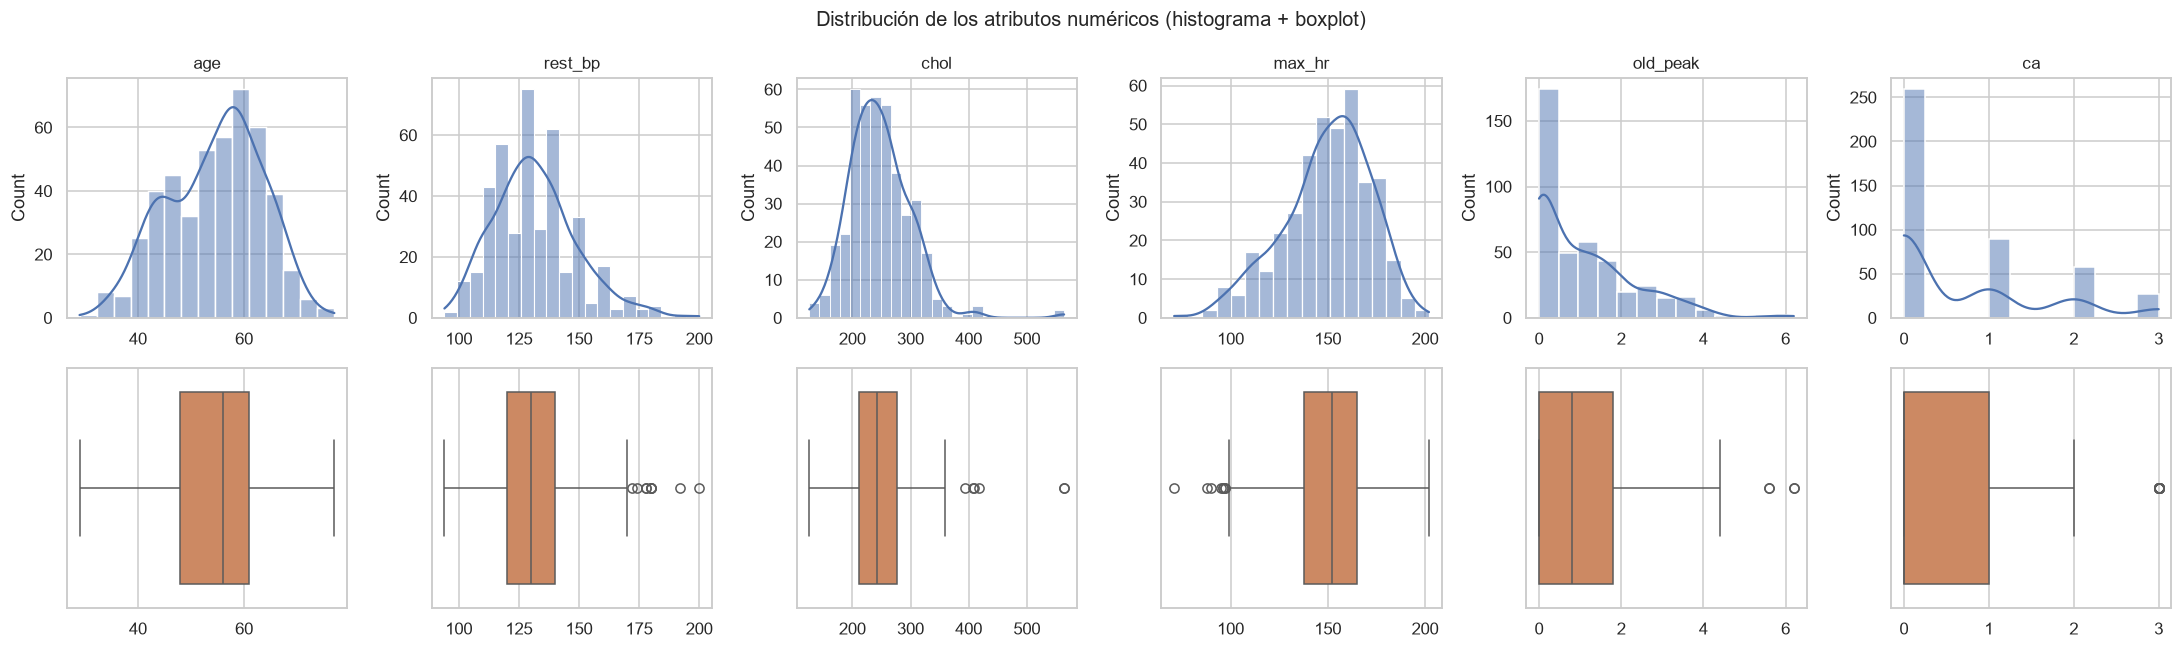

In [8]:
# Distribuciones: histograma + KDE y boxplot por atributo numerico
fig, axes = plt.subplots(2, len(NUMERICAS), figsize=(20, 6))
for i, col in enumerate(NUMERICAS):
    serie = corazon_eda[col].astype(float)
    sns.histplot(serie, kde=True, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(col, fontsize=11)
    axes[0, i].set_xlabel("")
    sns.boxplot(x=serie, ax=axes[1, i], color="#DD8452")
    axes[1, i].set_xlabel("")
fig.suptitle("Distribución de los atributos numéricos (histograma + boxplot)", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Deteccion de outliers por la regla del rango intercuartilico
filas = []
for col in NUMERICAS:
    serie = corazon_eda[col].astype(float).dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = serie[(serie < limite_inf) | (serie > limite_sup)]
    filas.append(
        {
            "atributo": col,
            "limite_inf": round(limite_inf, 2),
            "limite_sup": round(limite_sup, 2),
            "n_atipicos": atipicos.size,
            "pct": round(100 * atipicos.size / serie.size, 2),
            "max_observado": serie.max(),
        }
    )
pd.DataFrame(filas).set_index("atributo")

,limite_inf,limite_sup,n_atipicos,pct,max_observado
atributo,,,,,
age,28.50,80.50,0,0.00,77.0
rest_bp,90.00,170.00,10,2.43,200.0
chol,113.12,374.12,6,1.47,564.0
max_hr,97.50,205.50,8,2.05,202.0
old_peak,-2.70,4.50,4,0.98,6.2
ca,-1.50,2.50,27,6.24,3.0


### Atributos categóricos y booleanos

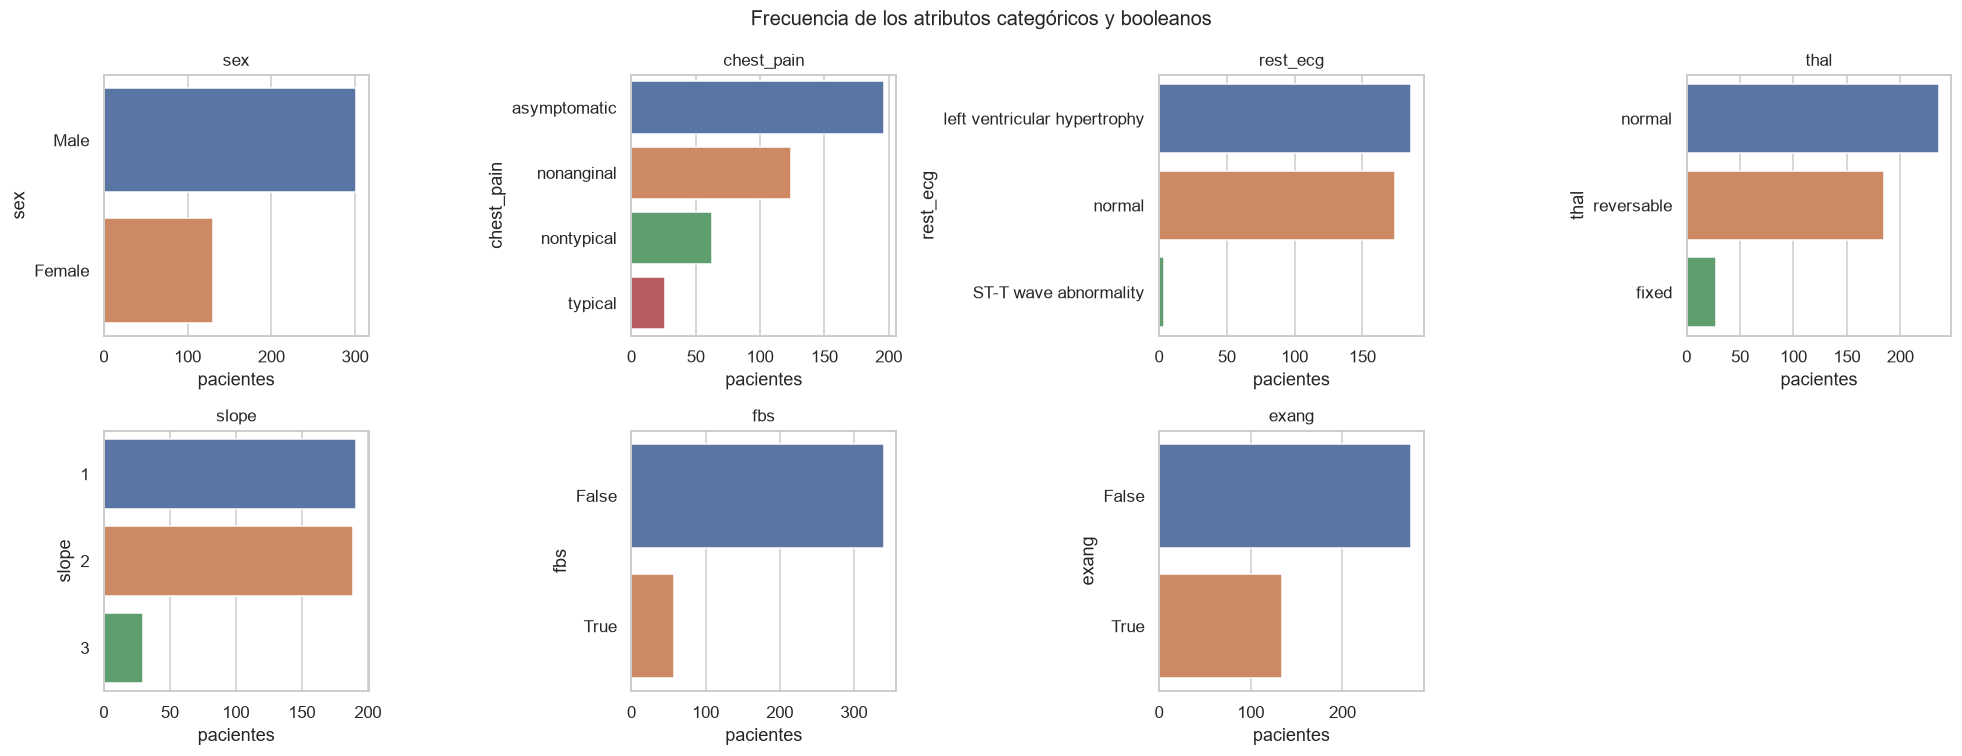

In [10]:
CATEGORICAS = ["sex", "chest_pain", "rest_ecg", "thal", "slope"]
BOOLEANAS = ["fbs", "exang"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), [*CATEGORICAS, *BOOLEANAS], strict=False):
    conteo = corazon_eda[col].astype(str).replace("<NA>", "nulo").value_counts()
    sns.barplot(x=conteo.values, y=conteo.index, ax=ax, hue=conteo.index, legend=False)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("pacientes")
axes.ravel()[-1].axis("off")
fig.suptitle("Frecuencia de los atributos categóricos y booleanos", fontsize=13)
plt.tight_layout()
plt.show()

### Atributo objetivo (target)

Para un problema de aprendizaje supervisado hay que identificar explícitamente el target:
es **`disease`** (booleano, 1 = el paciente tiene enfermedad cardíaca).

disease
False    250
True     230

Proporcion de la clase mayoritaria: 52.1%
Baseline trivial (predecir siempre la mayoritaria): 52.1% de accuracy


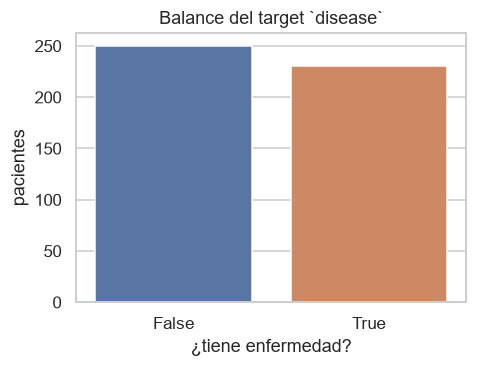

In [11]:
balance = corazon_eda["disease"].value_counts()
proporcion = corazon_eda["disease"].value_counts(normalize=True)
print(balance.to_string())
print()
print(f"Proporcion de la clase mayoritaria: {proporcion.max():.1%}")
print(f"Baseline trivial (predecir siempre la mayoritaria): {proporcion.max():.1%} de accuracy")

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.barplot(x=balance.index.astype(str), y=balance.values, ax=ax, hue=balance.index.astype(str), legend=False)
ax.set_title("Balance del target `disease`")
ax.set_xlabel("¿tiene enfermedad?")
ax.set_ylabel("pacientes")
plt.tight_layout()
plt.show()

## 2️⃣ Análisis bivariable

Relación de cada atributo con el target. Es lo que anticipa qué variables van a tener
poder predictivo.

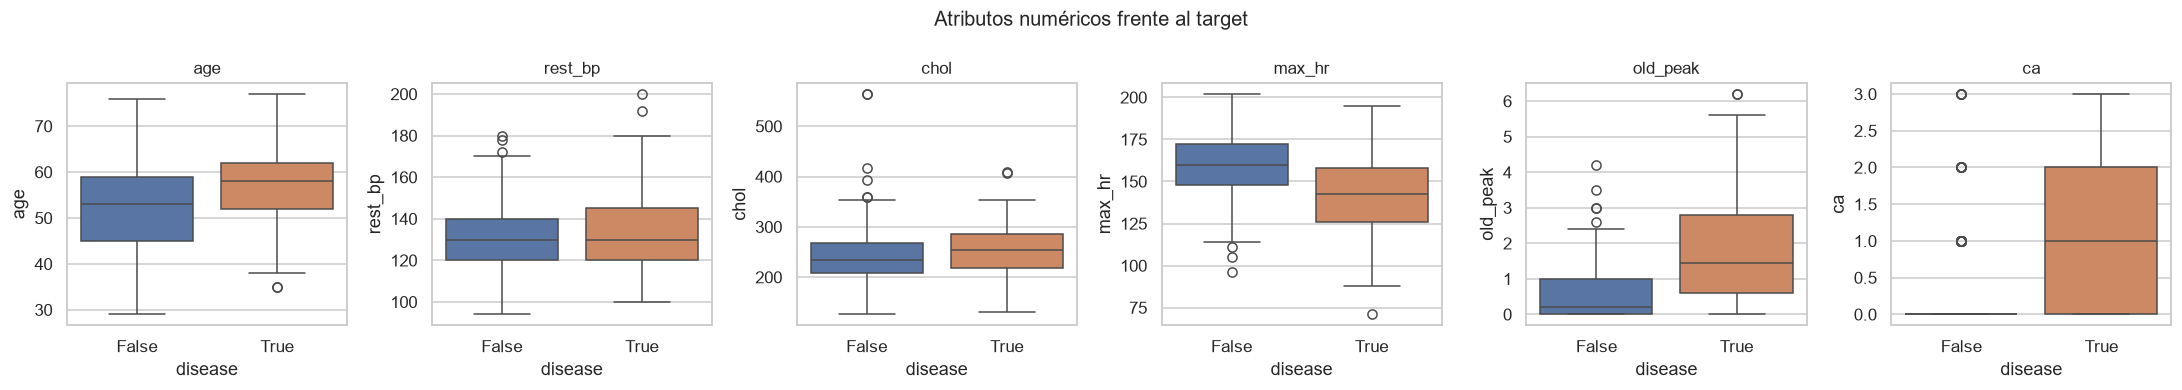

In [12]:
fig, axes = plt.subplots(1, len(NUMERICAS), figsize=(20, 3.6))
for ax, col in zip(axes, NUMERICAS, strict=False):
    datos = corazon_eda[[col, "disease"]].dropna().astype({col: float, "disease": str})
    sns.boxplot(data=datos, x="disease", y=col, ax=ax, hue="disease", legend=False)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("disease")
fig.suptitle("Atributos numéricos frente al target", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Significancia de la diferencia entre grupos (Mann-Whitney U, no asume normalidad)
filas = []
for col in NUMERICAS:
    datos = corazon_eda[[col, "disease"]].dropna()
    con = datos.loc[datos["disease"], col].astype(float)
    sin = datos.loc[~datos["disease"], col].astype(float)
    _, p_valor = stats.mannwhitneyu(con, sin)
    filas.append(
        {
            "atributo": col,
            "media_sin_enfermedad": round(sin.mean(), 2),
            "media_con_enfermedad": round(con.mean(), 2),
            "mannwhitney_p": f"{p_valor:.2e}",
            "significativo": p_valor < 0.05,
        }
    )
pd.DataFrame(filas).set_index("atributo").sort_values("significativo", ascending=False)

,media_sin_enfermedad,media_con_enfermedad,mannwhitney_p,significativo
atributo,,,,
age,52.66,56.58,5.02e-07,True
rest_bp,128.98,134.65,3.40e-03,True
chol,243.69,251.61,1.95e-02,True
max_hr,158.17,140.31,1.54e-15,True
old_peak,0.57,1.69,2.41e-20,True
ca,0.24,1.12,2.33e-25,True


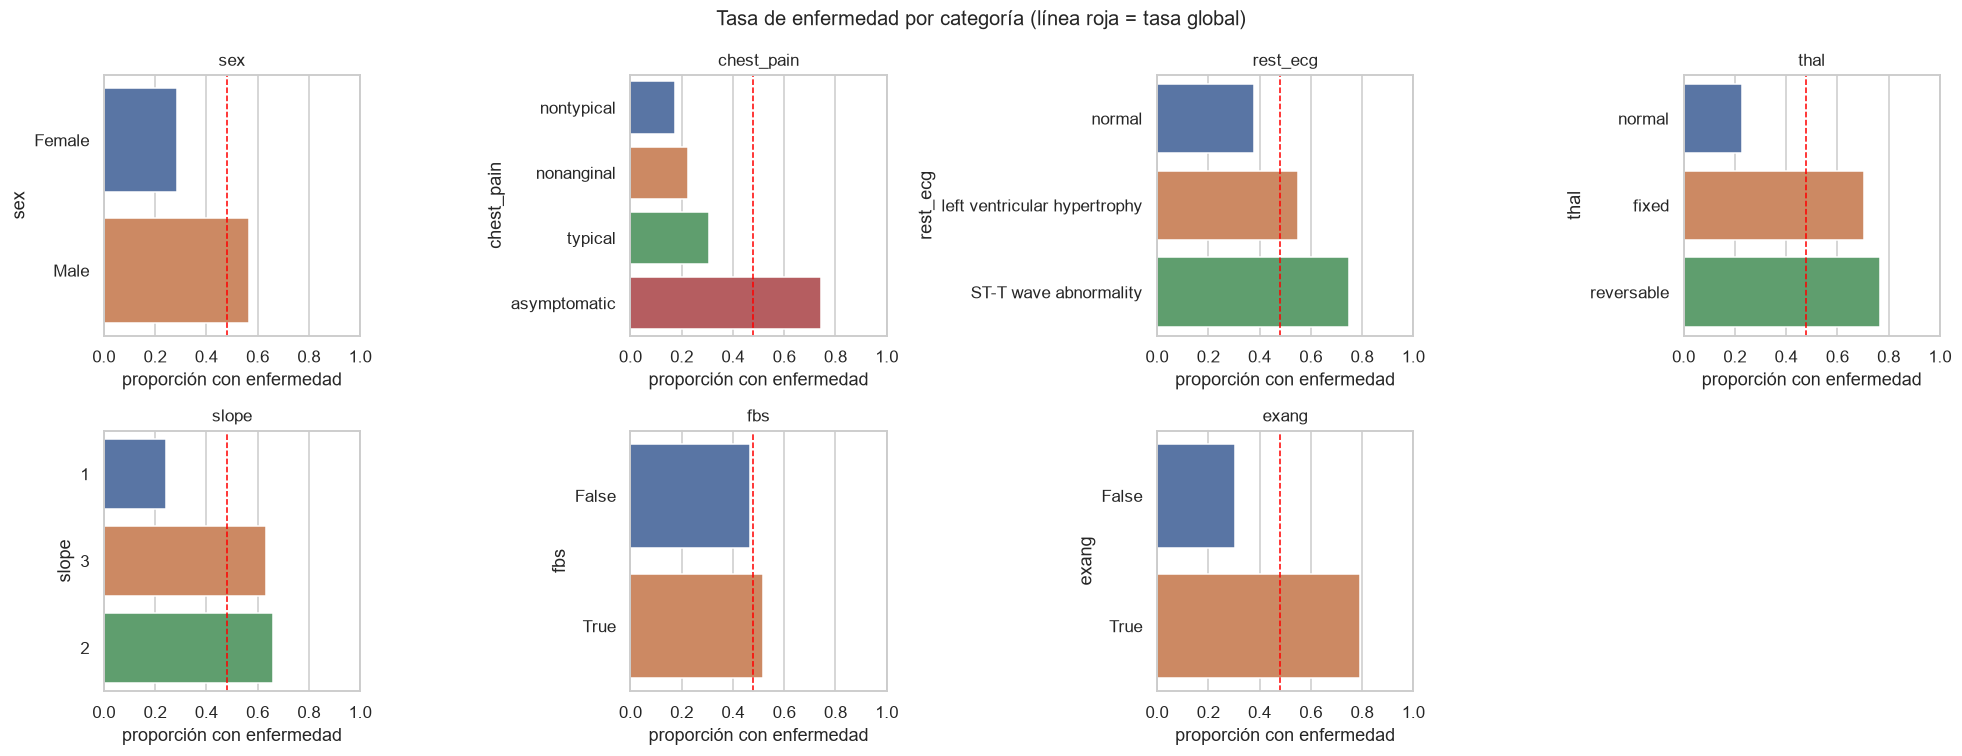

In [14]:
# Categoricas frente al target: proporcion de enfermos por categoria
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), [*CATEGORICAS, *BOOLEANAS], strict=False):
    datos = corazon_eda[[col, "disease"]].dropna()
    tasa = datos.groupby(col, observed=True)["disease"].mean().sort_values()
    sns.barplot(x=tasa.values, y=tasa.index.astype(str), ax=ax, hue=tasa.index.astype(str), legend=False)
    ax.axvline(corazon_eda["disease"].mean(), color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("proporción con enfermedad")
    ax.set_xlim(0, 1)
axes.ravel()[-1].axis("off")
fig.suptitle("Tasa de enfermedad por categoría (línea roja = tasa global)", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Asociacion de las categoricas con el target (chi-cuadrado + V de Cramer)
filas = []
for col in [*CATEGORICAS, *BOOLEANAS]:
    tabla = pd.crosstab(corazon_eda[col], corazon_eda["disease"])
    chi2, p_valor, _, _ = stats.chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    filas.append(
        {
            "atributo": col,
            "chi2": round(chi2, 2),
            "p_valor": f"{p_valor:.2e}",
            "cramer_v": round(cramer_v, 3),
            "significativo": p_valor < 0.05,
        }
    )
pd.DataFrame(filas).set_index("atributo").sort_values("cramer_v", ascending=False)

,chi2,p_valor,cramer_v,significativo
atributo,,,,
thal,126.36,3.63e-28,0.531,True
chest_pain,113.91,1.58e-24,0.528,True
exang,83.47,6.48e-20,0.452,True
slope,71.32,3.26e-16,0.417,True
sex,28.10,1.15e-07,0.255,True
rest_ecg,11.59,3.04e-03,0.178,True
fbs,0.31,5.78e-01,0.028,False


## 3️⃣ Análisis multivariable

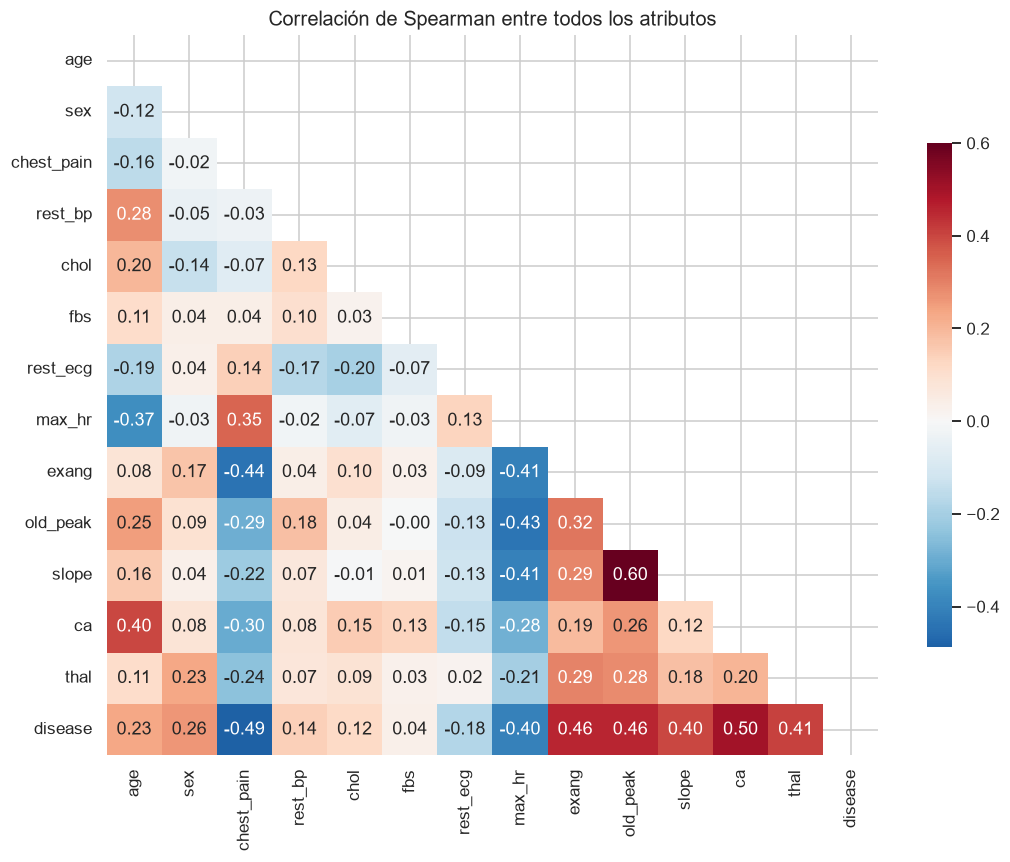

In [16]:
# Matriz de correlacion de Spearman (no asume linealidad ni normalidad)
numerico_completo = corazon_eda.copy()
for col in [*CATEGORICAS, *BOOLEANAS, "disease"]:
    if str(numerico_completo[col].dtype) == "category":
        numerico_completo[col] = numerico_completo[col].cat.codes.replace(-1, np.nan)
    else:
        numerico_completo[col] = numerico_completo[col].astype("Float64")
numerico_completo = numerico_completo.astype(float)

corr = numerico_completo.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlación de Spearman entre todos los atributos", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Correlacion de cada atributo con el target, ordenada por magnitud
corr_target = corr["disease"].drop("disease").sort_values(key=abs, ascending=False)
corr_target.to_frame("corr_spearman_con_disease").round(3)

,corr_spearman_con_disease
ca,0.501
chest_pain,-0.488
old_peak,0.457
exang,0.457
thal,0.406
max_hr,-0.404
slope,0.399
sex,0.260
age,0.234
rest_ecg,-0.177


In [18]:
# Colinealidad: pares de atributos con correlacion alta entre si
predictores = corr.drop(index="disease", columns="disease")
pares = (
    predictores.where(np.triu(np.ones(predictores.shape, dtype=bool), k=1))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print("Pares de predictores con |correlacion| > 0.30:")
print(pares[abs(pares) > 0.30].round(3).to_string())

Pares de predictores con |correlacion| > 0.30:
old_peak    slope       0.601
chest_pain  exang      -0.438
max_hr      old_peak   -0.433
            exang      -0.410
            slope      -0.406
age         ca          0.397
            max_hr     -0.370
chest_pain  max_hr      0.348
exang       old_peak    0.324


## 🧮 ¿Es viable un modelo heurístico?

El issue pide evaluar si se puede resolver el problema con reglas simples. Se construye
una heurística con las tres variables de mayor asociación con el target y se mide contra
el baseline trivial.

In [19]:
# Heuristica: contar señales de riesgo y decidir por mayoria
señales = pd.DataFrame(
    {
        "thal_anormal": corazon_eda["thal"].astype(str) != "normal",
        "vasos_afectados": corazon_eda["ca"].fillna(0) > 0,
        "dolor_asintomatico": corazon_eda["chest_pain"].astype(str) == "asymptomatic",
        "angina_ejercicio": corazon_eda["exang"].fillna(False),
        "oldpeak_alto": corazon_eda["old_peak"].fillna(0) > 1.0,
    }
)
puntaje = señales.sum(axis=1)
prediccion_heuristica = puntaje >= 3

real = corazon_eda["disease"].astype(bool)
verdaderos_pos = int((prediccion_heuristica & real).sum())
falsos_pos = int((prediccion_heuristica & ~real).sum())
falsos_neg = int((~prediccion_heuristica & real).sum())
verdaderos_neg = int((~prediccion_heuristica & ~real).sum())

exactitud = (verdaderos_pos + verdaderos_neg) / len(real)
sensibilidad = verdaderos_pos / (verdaderos_pos + falsos_neg)
precision = verdaderos_pos / (verdaderos_pos + falsos_pos)
baseline = real.value_counts(normalize=True).max()

print(f"Matriz de confusion: VP={verdaderos_pos} FP={falsos_pos} FN={falsos_neg} VN={verdaderos_neg}")
print()
print(f"Accuracy heuristica : {exactitud:.1%}")
print(f"Recall  heuristica  : {sensibilidad:.1%}")
print(f"Precision heuristica: {precision:.1%}")
print(f"Baseline trivial    : {baseline:.1%}")
print(f"Mejora sobre el baseline: {exactitud - baseline:+.1%}")

Matriz de confusion: VP=144 FP=14 FN=86 VN=236

Accuracy heuristica : 79.2%
Recall  heuristica  : 62.6%
Precision heuristica: 91.1%
Baseline trivial    : 52.1%
Mejora sobre el baseline: +27.1%


## ✅ Reglas de validación de datos

Reglas derivadas del EDA, para reutilizar en la validación del pipeline y en tests.

| Atributo | Regla |
| --- | --- |
| `age` | entero en [29, 77] observado; admitir [0, 120] |
| `sex` | ∈ {`Female`, `Male`} |
| `chest_pain` | ∈ {`asymptomatic`, `nonanginal`, `nontypical`, `typical`} |
| `rest_bp` | entero en [94, 200] observado; admitir [50, 250] |
| `chol` | entero en [126, 564] observado; admitir [100, 600] |
| `fbs` | booleano |
| `rest_ecg` | ∈ {`normal`, `ST-T wave abnormality`, `left ventricular hypertrophy`} |
| `max_hr` | entero en [71, 202] observado; admitir [60, 220] |
| `exang` | booleano |
| `old_peak` | decimal ≥ 0, observado ≤ 6.2; admitir [0, 10] |
| `slope` | ∈ {1, 2, 3} |
| `ca` | entero ∈ {0, 1, 2, 3} |
| `thal` | ∈ {`fixed`, `normal`, `reversable`} |
| `disease` | booleano, no nulo (fila inservible si falta) |

Reglas a nivel de dataset:

- No debe haber filas exactamente duplicadas en la capa `03_primary` en adelante.
- No debe haber grupos de exámenes idénticos con `disease` contradictorio.
- El target no se imputa nunca.

## 📊 Analysis of Results and Conclusions

1. **El tamaño muestral real es de unos pocos cientos de pacientes**, no 3030. Es la
   conclusión que más condiciona el proyecto: obliga a validación cruzada, desaconseja
   modelos de alta capacidad y exige prudencia con cualquier análisis por subgrupos.

2. **Las variables del examen de esfuerzo y la perfusión son las más discriminantes.**
   `thal`, `ca`, `chest_pain`, `exang`, `old_peak` y `max_hr` concentran la señal, tanto
   por correlación de Spearman con el target como por las pruebas de asociación
   (chi-cuadrado / Mann-Whitney). Coincide con el criterio clínico: la isquemia inducida
   por ejercicio es lo que mejor delata la enfermedad coronaria.

3. **`chol` y `fbs` aportan poco.** El colesterol sérico y la glucemia en ayunas apenas
   se asocian con el target en esta muestra, pese a ser factores de riesgo
   cardiovascular reconocidos. Es esperable: son factores de riesgo *a largo plazo*, no
   marcadores del estado coronario en el momento del examen.

4. **Las distribuciones no son gaussianas.** Shapiro-Wilk rechaza la normalidad en la
   práctica totalidad de los atributos numéricos, y `old_peak` y `chol` muestran una
   asimetría a la derecha marcada. Esto justifica usar pruebas no paramétricas en el EDA
   y escalado robusto o transformaciones en el modelado.

5. **Hay outliers, pero son clínicamente plausibles.** Los valores atípicos por la regla
   del IQR (sobre todo en `chol` y `old_peak`) corresponden a pacientes reales con
   valores extremos, no a errores de captura: ya se verificó en el issue #8 que todo cae
   dentro de rangos fisiológicos. **No deben eliminarse**; conviene absorberlos con un
   escalado robusto.

6. **La colinealidad es moderada.** No hay pares de predictores con correlación alta que
   obliguen a descartar variables, así que se pueden conservar los 13 atributos.

7. **El modelo heurístico es viable como referencia, pero insuficiente como solución.**
   Contando señales de riesgo se supera el baseline trivial, lo que confirma que la
   señal existe y es explotable con reglas simples. Aun así se queda por debajo del
   objetivo de recall del proyecto: justifica seguir con modelos de machine learning y
   sirve como segundo punto de comparación junto al `DummyClassifier`.

### Transformaciones identificadas para el feature engineering

- **Imputación**: mediana para las numéricas asimétricas, moda o categoría `desconocido`
  para las categóricas. Siempre dentro del pipeline, ajustada solo con train.
- **Escalado robusto** (`RobustScaler`) en las numéricas, por los outliers legítimos.
- **Transformación logarítmica o `PowerTransformer`** para `old_peak` y `chol`, que son
  las más asimétricas.
- **One-hot** para `sex`, `chest_pain`, `rest_ecg` y `thal`; **ordinal** para `slope`;
  `ca` puede quedarse como conteo.
- **Discretización de `age`** en grupos etarios como atributo adicional a evaluar.

### Datos adicionales que serían útiles

Tabaquismo, diabetes, índice de masa corporal, antecedentes familiares y medicación
actual: son los grandes factores de riesgo cardiovascular ausentes en este dataset, y
explicarían parte del error residual del modelo.

## 💡 Proposals and Ideas

1. **Siguiente etapa (issue #11)**: construir el pipeline de scikit-learn con las
   transformaciones listadas arriba. La deduplicación y el descarte de targets inválidos
   van **fuera** del pipeline (cambian el número de filas) y **antes** del
   `train_test_split`.
2. **Estratificar el split por `disease`**, dado el tamaño muestral reducido.
3. **Usar `RobustScaler` en vez de `StandardScaler`** por los outliers legítimos.
4. **Llevar la heurística de este notebook al issue #12** como segundo baseline, junto al
   `DummyClassifier`.
5. **Evaluar si `chol` y `fbs` aportan** al modelo final: son candidatas a descartarse en
   la selección de atributos si no mejoran el desempeño.
6. **Priorizar recall** en la selección del modelo: el falso negativo (dar por sano a un
   enfermo) es el error caro.

## 📖 References

- Metodología de la etapa: [Jose R. Zapata - Proyecto de ciencia de datos: 3. Analysis](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/).
- Notebook anterior: `notebooks/2-exploration/02-jrdt-exploracion_inicial-2026_08_21.ipynb` (issue #8).
- Diccionario de variables: `data/01_raw/datos_corazon_Info.txt`.
- [Documentación de seaborn](https://seaborn.pydata.org/) y [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html).